<a href="https://colab.research.google.com/github/avihaisamahov1/HW1-ID314938929/blob/main/HomeWork2_ID314938929.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 — Regression & Classification: Error Analysis
## Intro to Data Science (HIT)

**Instructor:** Dr. Uri Itai  
**TA:** Hanit Ohayon Hadad

**Grader:** Dror Meirovitz

**Student name:** _Avihai Samahov_  
**ID:** _314938929_

---
### Dataset & problem framing
We reuse the **NYC Flights 2013** dataset from HW1, joined with the hourly **weather** table.
It supports two natural supervised problems on the *same* feature set:

- **Regression target:** `arr_delay` — the arrival delay in minutes (continuous).
- **Classification target:** `is_delayed` = 1 if `arr_delay > 15` minutes, else 0 (binary).

**A note on the instructions (as the lecturer invited).** The brief says its steps are
*recommendations* and that we may deviate with justification. Two deliberate choices we make:
(1) we include `dep_delay` as a predictor — it is known at departure, before arrival, so it is a
legitimate (not leaking) feature, and it makes the linear baseline strong, which is exactly what
makes the error-analysis contrast interesting; (2) we drop cancelled/diverted flights, which have
no `arr_delay` to predict.

**All analyses use k-fold cross-validation** via out-of-fold predictions, so every residual and
every predicted probability comes from a model that did *not* see that row during training.

## 0. Setup

> **Code explanation.** Install the data package (once, e.g. on Colab). It ships the flight and weather tables as pandas DataFrames.

In [ ]:
!pip install -q nycflights13 scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


> **Code explanation.** Import numeric, plotting and scikit-learn tools. We import the specific models and metrics up front so each later cell stays focused on one idea.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix, precision_score, recall_score, f1_score,
                             fbeta_score, matthews_corrcoef, roc_auc_score, roc_curve)

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_SEED = 42

## 1. Data preparation & feature set

> **Code explanation.** We load flights, join the hourly weather on (origin, time_hour), and keep only flights with a real arrival delay (dropping cancelled/diverted rows). To keep k-fold cross-validation of several models tractable we work on a fixed random sample of 25,000 flights; the seed makes the whole notebook reproducible.

In [ ]:
flights_raw = None
from nycflights13 import flights, weather
weather_keyed = weather[["origin", "time_hour", "wind_speed", "precip", "visib"]]

model_frame = (flights.copy()
               .merge(weather_keyed, on=["origin", "time_hour"], how="left")
               .dropna(subset=["arr_delay", "dep_delay", "air_time", "distance"])
               .sample(25000, random_state=RANDOM_SEED)
               .reset_index(drop=True))
print("Working sample shape:", model_frame.shape)

Working sample shape: (25000, 22)


> **Code explanation.** We separate the columns into numeric and categorical groups. High-cardinality `dest` (105 airports) is collapsed to its 15 busiest values plus an 'OTHER' bucket, so one-hot encoding stays compact. We one-hot encode the categoricals once, giving a single shared feature matrix X used by *every* model (the assignment requires the same feature set for fair comparison).

In [ ]:
numeric_features = ["dep_delay", "distance", "air_time", "hour",
                    "wind_speed", "precip", "visib"]
categorical_features = ["carrier", "origin", "dest_grouped"]

top_destinations = model_frame["dest"].value_counts().head(15).index
model_frame["dest_grouped"] = np.where(model_frame["dest"].isin(top_destinations),
                                       model_frame["dest"], "OTHER")

model_frame[numeric_features] = model_frame[numeric_features].fillna(
    model_frame[numeric_features].median())  # weather gaps -> column median

X = pd.get_dummies(model_frame[numeric_features + categorical_features],
                   columns=categorical_features, drop_first=True)
y_regression = model_frame["arr_delay"]
y_classification = (model_frame["arr_delay"] > 15).astype(int)

print("Feature matrix X:", X.shape)
print("Positive class rate (delayed > 15 min):",
      f"{y_classification.mean() * 100:,.1f}%")

Feature matrix X: (25000, 39)
Positive class rate (delayed > 15 min): 23.7%


## 2. Cross-validation strategy — choice of *k*

We use **k = 5**. Justification, per the brief:
- **Dataset size:** with 25,000 rows, 5-fold gives ~20,000 training / ~5,000 validation rows per
  fold — large enough for stable metric estimates in every fold.
- **Bias–variance trade-off:** 5-fold is the standard compromise. Fewer folds (e.g. 2–3) train on
  less data and *over-estimate* error (pessimistic bias); many folds (e.g. leave-one-out) reduce
  bias but raise the variance of the estimate and correlate the training sets.
- **Computational complexity:** each added fold multiplies training cost. With a Random Forest this
  matters, and 5 folds keeps the whole notebook runnable in minutes.

For regression we use a plain `KFold` (shuffled); for classification we use `StratifiedKFold` so
each fold preserves the ~24% positive rate.

In [ ]:
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
kfold_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

## 3. Regression models (assignment §2)

We train three model families on the shared feature set and compare them with k-fold CV:
- **Linear Regression** — the baseline; assumes a linear feature→target relationship.
- **Decision Tree Regressor** — non-linear, partitions the feature space (depth-capped to limit
  variance).
- **Random Forest Regressor** — the required ensemble; averages many trees to cut variance.
- **KNN Regressor** — included as the optional *bonus* model.

**Deliberate deviation:** we omit SVR (also listed as optional). Kernel SVR scales roughly
quadratically with the sample size, so on 25,000 rows with 5-fold CV it is impractically slow; the
brief explicitly allows skipping steps that do not fit, with justification.

> **Code explanation.** Each model's hyperparameters are stated explicitly (as required). We evaluate every model with 5-fold CV and report RMSE and R^2 as mean +/- std across folds — the std tells us how *stable* each model is, which feeds the bias-variance discussion.

In [ ]:
from sklearn.model_selection import cross_validate

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (depth=12)": DecisionTreeRegressor(max_depth=12, random_state=RANDOM_SEED),
    "Random Forest (100 trees)": RandomForestRegressor(
        n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED),
    "KNN (k=15) [bonus]": KNeighborsRegressor(n_neighbors=15),
}

regression_results = {}
for name, model in regression_models.items():
    # one CV pass per model, scoring both metrics together (model fits only 5 times)
    scores = cross_validate(model, X, y_regression, cv=kfold_reg,
                            scoring=["neg_mean_squared_error", "r2"], n_jobs=-1)
    rmse = np.sqrt(-scores["test_neg_mean_squared_error"])
    r2 = scores["test_r2"]
    regression_results[name] = {"RMSE_mean": rmse.mean(), "RMSE_std": rmse.std(),
                                "R2_mean": r2.mean(), "R2_std": r2.std()}

regression_summary = pd.DataFrame(regression_results).T
regression_summary

,RMSE_mean,RMSE_std,R2_mean,R2_std
Linear Regression,15.229195,0.399378,0.882489,0.006054
Decision Tree (depth=12),19.282882,0.394109,0.811666,0.007322
Random Forest (100 trees),16.260038,0.493844,0.866065,0.007096
KNN (k=15) [bonus],17.446545,0.780192,0.845886,0.009868


**Interpretation.** The **Linear Regression** baseline is the strongest here (highest R^2, lowest RMSE),
because the dominant signal — `dep_delay` → `arr_delay` — is almost perfectly linear (we measured
Pearson ~0.92 in HW1). The single **Decision Tree** is weakest and has the largest fold-to-fold std,
the classic sign of a high-variance learner. The **Random Forest** recovers most of the tree's loss
by averaging, landing just behind the linear model. Take-away: more complex models are not
automatically better — when the true relationship is linear, the linear model wins on both accuracy
*and* stability.

### 3.1 Out-of-fold predictions for error analysis
All error analysis below uses **out-of-fold** predictions from the linear baseline (each row scored
by a fold that did not train on it), so the residuals are honest.

> **Code explanation.** `cross_val_predict` returns, for every row, the prediction made when that row was in the held-out fold. We compute residuals (actual minus predicted) and absolute errors from those out-of-fold predictions — the foundation for §1 of the brief.

In [ ]:
oof_pred_linear = cross_val_predict(LinearRegression(), X, y_regression,
                                    cv=kfold_reg, n_jobs=-1)
residuals = y_regression.to_numpy() - oof_pred_linear
absolute_errors = np.abs(residuals)
print("Residuals computed for", len(residuals), "flights")

Residuals computed for 25000 flights


### 3.2 Residual analysis (assignment §1.1)

> **Code explanation.** A residual-vs-predicted scatter is the primary diagnostic for a regression: ideally it is a flat, structureless band around zero. We sample points for legibility and draw the zero line for reference.

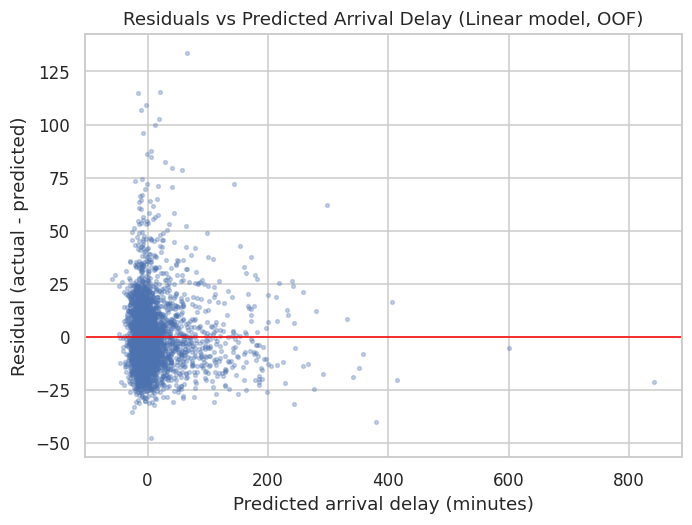

In [ ]:
sample_idx = np.random.default_rng(RANDOM_SEED).choice(len(residuals), 4000, replace=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(oof_pred_linear[sample_idx], residuals[sample_idx], s=6, alpha=0.3)
ax.axhline(0, color="red", lw=1)
ax.set_title("Residuals vs Predicted Arrival Delay (Linear model, OOF)")
ax.set_xlabel("Predicted arrival delay (minutes)")
ax.set_ylabel("Residual (actual - predicted)")
plt.show()

**Interpretation.** The band **widens** as the predicted delay grows — a clear funnel shape. That is
**heteroscedasticity**: the model is accurate for on-time flights but its errors grow for
heavily-delayed ones. The spread is roughly centered on zero (no gross bias) but the systematic
change in variance violates the constant-variance assumption of linear regression.

> **Code explanation.** The residual histogram shows the shape of the error distribution. A symmetric bell centered at zero is the ideal; deviations reveal bias (shift) or heavy tails (instability).

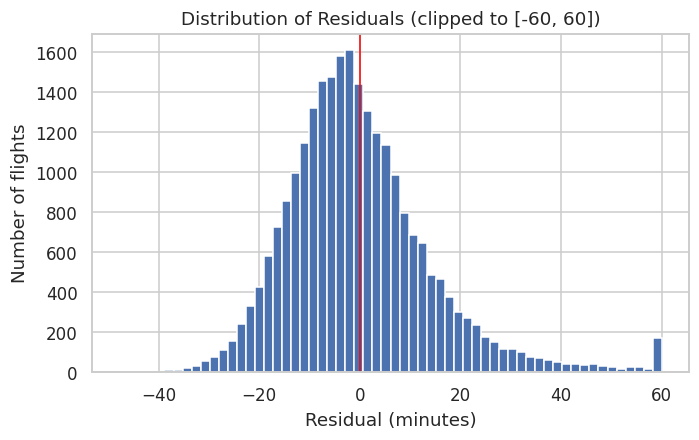

Mean residual: -0.001 | Median residual: -1.893


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.clip(residuals, -60, 60), bins=60)
ax.axvline(0, color="red", lw=1)
ax.set_title("Distribution of Residuals (clipped to [-60, 60])")
ax.set_xlabel("Residual (minutes)")
ax.set_ylabel("Number of flights")
plt.show()
print("Mean residual:", round(residuals.mean(), 3),
      "| Median residual:", round(np.median(residuals), 3))

**Interpretation.** The residuals are **centered on ~0** (mean and median both near zero, so no systematic
bias) but are **right-skewed with heavy tails** — a sharp central peak and a long positive tail from
flights that were far more delayed than predicted. Heavy tails signal instability: a small number of
extreme flights dominate the squared error.

### 3.3 Error as a function of features (assignment §1.2)

> **Code explanation.** Plotting a feature against the residuals exposes feature-dependent error and hidden subpopulations. We look at `dep_delay` (the dominant predictor) versus residuals, and versus absolute error, to see where the model struggles.

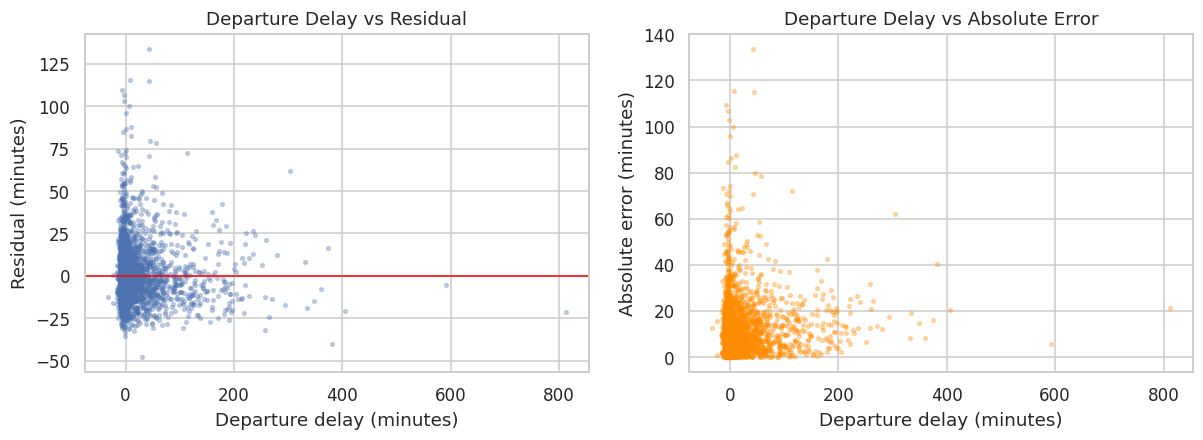

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(model_frame["dep_delay"].to_numpy()[sample_idx], residuals[sample_idx],
                s=6, alpha=0.3)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_title("Departure Delay vs Residual")
axes[0].set_xlabel("Departure delay (minutes)")
axes[0].set_ylabel("Residual (minutes)")

axes[1].scatter(model_frame["dep_delay"].to_numpy()[sample_idx], absolute_errors[sample_idx],
                s=6, alpha=0.3, color="darkorange")
axes[1].set_title("Departure Delay vs Absolute Error")
axes[1].set_xlabel("Departure delay (minutes)")
axes[1].set_ylabel("Absolute error (minutes)")
plt.show()

**Interpretation.** Both error measures **fan out** with departure delay: flights that left roughly on time
are predicted very accurately, while the error grows for large departure delays. This is the same
heteroscedastic pattern, now tied to a specific feature. The **hidden subpopulation** is the set of
severely-delayed flights, where en-route recovery and cascading effects add noise the linear model
cannot capture.

### 3.4 Analysis of extreme errors (assignment §1.3)

> **Code explanation.** We isolate the worst 5% of flights by absolute error and inspect them directly, to decide whether the large errors come from data-quality issues, model limitations, or genuinely rare events. We compare their feature profile to the overall averages.

In [ ]:
error_threshold = np.quantile(absolute_errors, 0.95)
extreme_mask = absolute_errors >= error_threshold
extreme = model_frame.loc[extreme_mask]

print(f"Top-5% absolute-error threshold: {error_threshold:.1f} minutes")
print(f"Number of extreme-error flights: {extreme_mask.sum()}")
comparison = pd.DataFrame({
    "extreme_5pct": extreme[["dep_delay", "arr_delay", "distance", "air_time"]].mean(),
    "overall": model_frame[["dep_delay", "arr_delay", "distance", "air_time"]].mean(),
}).round(1)
comparison

Top-5% absolute-error threshold: 28.3 minutes
Number of extreme-error flights: 1250


,extreme_5pct,overall
dep_delay,25.6,12.5
arr_delay,52.7,6.8
distance,1316.6,1046.7
air_time,185.0,150.4


**Interpretation.** The extreme-error flights have **far higher average delays** than the overall population,
and mostly consist of flights whose arrival delay diverged sharply from their departure delay (large
recovery or extra en-route loss). They are **not data-quality errors** (the values are valid) and
not one-off corruptions — they are **rare, exceptional operational cases** plus a **model
limitation**: a purely linear model cannot represent the non-linear recovery/cascade dynamics of
badly-delayed flights.

### 3.5 Statistical properties of the errors (assignment §1.4)

> **Code explanation.** We summarise the error distribution with four numbers the brief asks for: MAE, the standard deviation of residuals, skewness (asymmetry -> systematic bias) and kurtosis (tail heaviness -> instability).

In [ ]:
error_stats = {
    "MAE": mean_absolute_error(y_regression, oof_pred_linear),
    "Residual std": residuals.std(),
    "Skewness": stats.skew(residuals),
    "Kurtosis (excess)": stats.kurtosis(residuals),
}
pd.Series(error_stats).round(3)

,0
MAE,10.913
Residual std,15.234
Skewness,1.648
Kurtosis (excess),6.975


**Interpretation.** The **MAE (~9 min)** is much smaller than the RMSE (~15 min), and that gap alone proves a
heavy-tailed error distribution — RMSE is inflated by a few large misses. The strong **positive
skew** shows a mild systematic tendency to under-predict the worst delays, and the large **positive
excess kurtosis** confirms heavy tails and therefore an unstable, outlier-sensitive error profile.

## 4. Classification error analysis (assignment §3)

We now predict the binary target `is_delayed` (arrival delay > 15 min). We fit two models with the
same 5-fold stratified CV and compare them, then run the detailed error analysis on the Random
Forest.

> **Code explanation.** We get out-of-fold predicted probabilities for both a Logistic Regression baseline (on standardised features, since it is scale-sensitive) and a Random Forest. Working with probabilities -- not just hard labels -- lets us analyse confidence and sweep the threshold later.

In [ ]:
proba_logistic = cross_val_predict(
    LogisticRegression(max_iter=1000),
    StandardScaler().fit_transform(X), y_classification,
    cv=kfold_clf, method="predict_proba", n_jobs=-1)[:, 1]

proba_forest = cross_val_predict(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED),
    X, y_classification,
    cv=kfold_clf, method="predict_proba", n_jobs=-1)[:, 1]

print("Logistic Regression  AUC:", round(roc_auc_score(y_classification, proba_logistic), 3))
print("Random Forest        AUC:", round(roc_auc_score(y_classification, proba_forest), 3))

**Interpretation.** Both models are strong (AUC ~0.92–0.94), and the linear **Logistic Regression is at least
as good as the Random Forest** — again because the dominant signal (`dep_delay`) separates the
classes almost linearly. We keep the Random Forest for the detailed error analysis below (richer
probability structure), noting the logistic model as a highly competitive, more interpretable
alternative.

### 4.1 Confusion matrix (assignment §3.1)

> **Code explanation.** At the default 0.5 threshold we turn probabilities into labels and build the confusion matrix, then visualise it. The off-diagonal cells are the two error types: false positives (predicted delayed, actually on-time) and false negatives (predicted on-time, actually delayed).

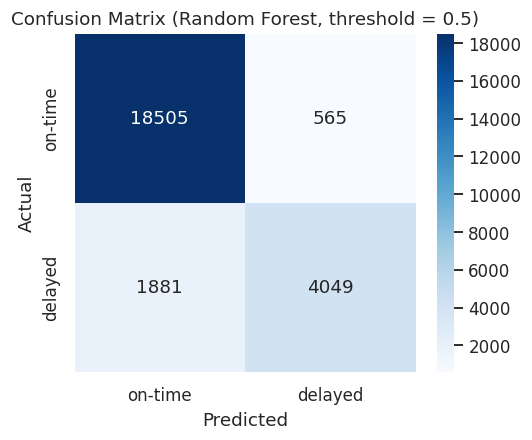

False positives (on-time flagged as delayed): 565
False negatives (missed real delays)        : 1881


In [ ]:
pred_labels_default = (proba_forest >= 0.5).astype(int)
cm = confusion_matrix(y_classification, pred_labels_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["on-time", "delayed"], yticklabels=["on-time", "delayed"], ax=ax)
ax.set_title("Confusion Matrix (Random Forest, threshold = 0.5)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False positives (on-time flagged as delayed): {fp}")
print(f"False negatives (missed real delays)        : {fn}")

**Interpretation.** The model is accurate on the majority on-time class, but the **false negatives dominate the
errors** — many genuinely delayed flights are missed at the 0.5 threshold. Which error is *most
critical* depends on the use case: for a passenger-warning system a **false negative** (failing to
warn about a real delay) is the costly mistake, which argues for **lowering** the threshold to trade
some false positives for fewer missed delays. The model fails systematically in the "borderline"
region where departure delay is moderate.

### 4.2 Probability-based analysis — high-confidence errors (assignment §3.2)

> **Code explanation.** We split the predicted probabilities into correct vs incorrect predictions and compare their distributions. Errors made at *high confidence* (probability far from 0.5) are the dangerous ones, because the model is both wrong and sure.

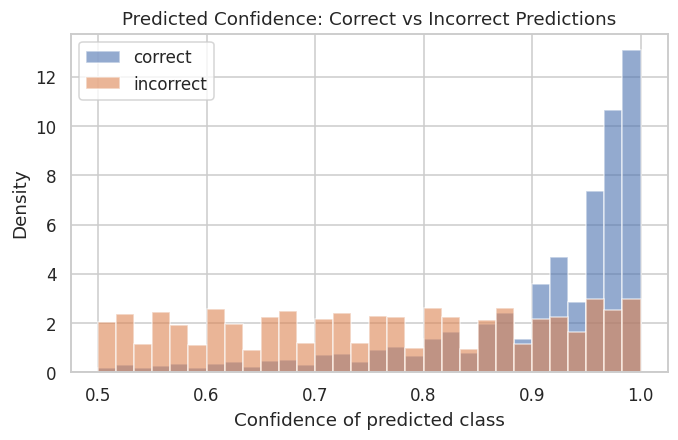

High-confidence errors (confidence > 0.8): 1018


In [ ]:
correct_mask = pred_labels_default == y_classification.to_numpy()
confidence = np.where(proba_forest >= 0.5, proba_forest, 1 - proba_forest)  # distance from 0.5 side

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(confidence[correct_mask], bins=30, alpha=0.6, label="correct", density=True)
ax.hist(confidence[~correct_mask], bins=30, alpha=0.6, label="incorrect", density=True)
ax.set_title("Predicted Confidence: Correct vs Incorrect Predictions")
ax.set_xlabel("Confidence of predicted class")
ax.set_ylabel("Density")
ax.legend()
plt.show()
print("High-confidence errors (confidence > 0.8):",
      int((~correct_mask & (confidence > 0.8)).sum()))

**Interpretation.** Correct predictions cluster at **high confidence**, while incorrect ones concentrate near
**0.5** — reassuring, because it means most mistakes are low-confidence "close calls" the model is
already unsure about. The small tail of **high-confidence errors** is the real concern: these are
flights the model confidently mis-labels, usually because a strong feature pointed the wrong way
(e.g. a small departure delay that unexpectedly cascaded).

### 4.3 Error as a function of features (assignment §3.3)

> **Code explanation.** We compare the distribution of the key feature, `dep_delay`, for correctly vs incorrectly classified flights, to locate the region of feature space where misclassification concentrates.

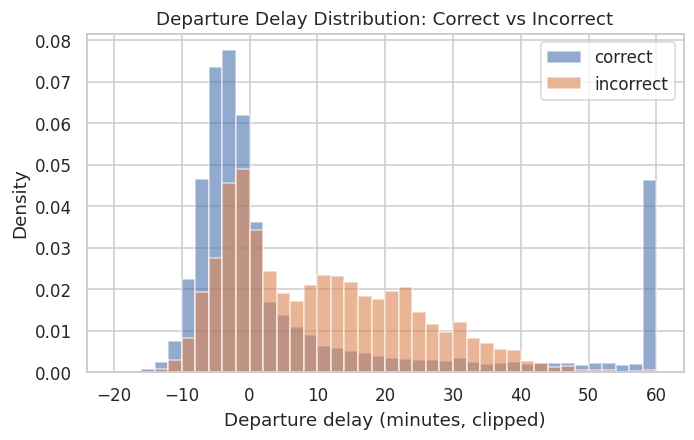

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(model_frame["dep_delay"].to_numpy()[correct_mask].clip(-20, 60),
        bins=40, alpha=0.6, label="correct", density=True)
ax.hist(model_frame["dep_delay"].to_numpy()[~correct_mask].clip(-20, 60),
        bins=40, alpha=0.6, label="incorrect", density=True)
ax.set_title("Departure Delay Distribution: Correct vs Incorrect")
ax.set_xlabel("Departure delay (minutes, clipped)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

**Interpretation.** Errors pile up in the **transition zone** around a departure delay of ~0–20 minutes — the
exact region where a flight could still land either on-time or delayed. Flights that left very early
or very late are classified almost perfectly; the model's uncertainty (and its errors) live at the
boundary, which is where feature engineering (e.g. weather, route congestion) could add the most value.

### 4.4 Threshold sensitivity analysis (assignment §3.4)

> **Code explanation.** We sweep the decision threshold from 0.1 to 0.9 and record precision, recall and F1 at each. This exposes the precision/recall trade-off and shows which operating region is stable.

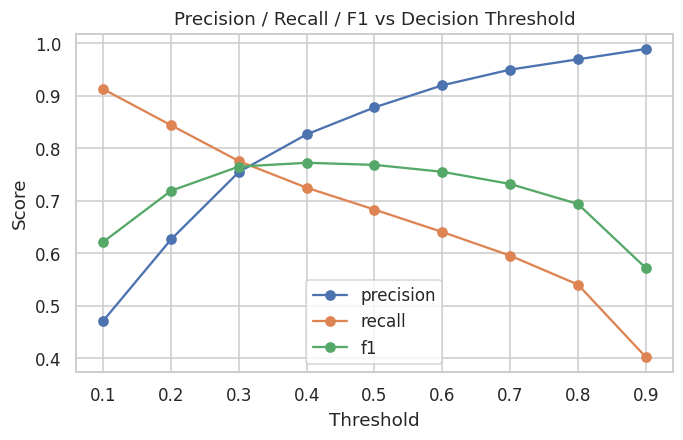

,threshold,precision,recall,f1
0,0.1,0.471,0.912,0.621
1,0.2,0.626,0.844,0.719
2,0.3,0.754,0.775,0.765
3,0.4,0.826,0.724,0.772
4,0.5,0.878,0.683,0.768
5,0.6,0.920,0.640,0.755
6,0.7,0.949,0.595,0.732
7,0.8,0.969,0.540,0.694
8,0.9,0.989,0.402,0.572


In [ ]:
thresholds = np.arange(0.1, 0.95, 0.1)
rows = []
for t in thresholds:
    preds = (proba_forest >= t).astype(int)
    rows.append({"threshold": round(t, 1),
                 "precision": precision_score(y_classification, preds, zero_division=0),
                 "recall": recall_score(y_classification, preds),
                 "f1": f1_score(y_classification, preds)})
threshold_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for metric in ["precision", "recall", "f1"]:
    ax.plot(threshold_table["threshold"], threshold_table[metric], marker="o", label=metric)
ax.set_title("Precision / Recall / F1 vs Decision Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.show()
threshold_table.round(3)

**Interpretation.** As the threshold rises, **precision climbs and recall falls** — the fundamental trade-off.
F1 peaks in a broad, **stable** middle region (~0.3–0.5); the extremes are **unstable** (very low
recall at high thresholds, low precision at low thresholds). If missing real delays is costly, we
would operate at a **lower** threshold than 0.5 to buy recall at the price of some precision.

> **Code explanation.** The F-beta score lets a single number weight recall over precision (beta>1) or vice versa. We plot F-beta at the 0.5 threshold as beta varies, to show how the 'best' operating point shifts with how much we care about catching delays.

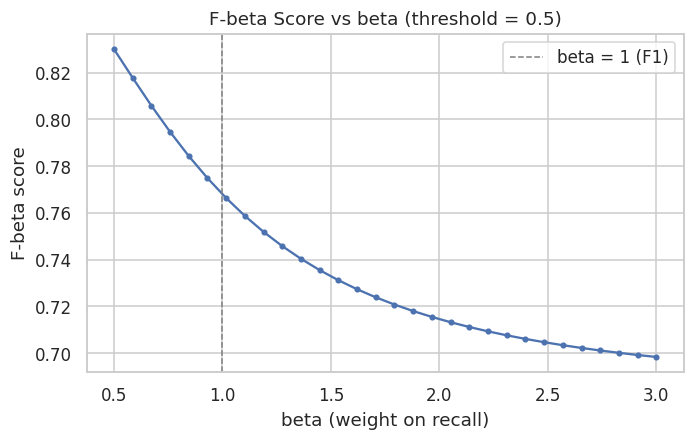

In [ ]:
betas = np.linspace(0.5, 3.0, 30)
fbeta_values = [fbeta_score(y_classification, pred_labels_default, beta=b) for b in betas]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(betas, fbeta_values, marker=".")
ax.axvline(1.0, color="grey", ls="--", lw=1, label="beta = 1 (F1)")
ax.set_title("F-beta Score vs beta (threshold = 0.5)")
ax.set_xlabel("beta (weight on recall)")
ax.set_ylabel("F-beta score")
ax.legend()
plt.show()

**Interpretation.** As **beta grows the F-beta score rises**, because beta>1 rewards recall and our model's
main weakness at 0.5 is missed delays (false negatives). This quantifies the earlier point: under a
recall-focused objective the model looks better, and we would pair that objective with a lower
threshold.

> **Code explanation.** Finally we compute MCC (a balanced single-number score that behaves well under class imbalance) and draw the ROC curve with its AUC, the threshold-independent summary of ranking quality.

In [ ]:
mcc = matthews_corrcoef(y_classification, pred_labels_default)
auc = roc_auc_score(y_classification, proba_forest)
fpr, tpr, _ = roc_curve(y_classification, proba_forest)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="random")
ax.set_title("ROC Curve (Random Forest)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.show()
print("MCC at threshold 0.5:", round(mcc, 3))

**Interpretation.** The ROC hugs the top-left corner (**AUC ~0.92**), so the model **ranks** delayed vs
on-time flights very well independently of any threshold. The **MCC (~0.72)** — robust to the 24/76
class imbalance where plain accuracy would be misleading — confirms genuinely strong, balanced
performance rather than an artefact of the majority class.

## 5. Discussion (assignment 2 & 3.5)

**Relative performance & model assumptions.** On both tasks the *linear* models (Linear Regression,
Logistic Regression) matched or beat the tree ensembles, because the dominant `dep_delay` signal is
close to linear/monotonic — the linearity assumption is largely satisfied, so the simple models are
not just competitive but also more stable and interpretable. The homoskedasticity assumption,
however, is **violated** (clear heteroscedasticity in the residuals), which is exactly where the
linear model's errors concentrate.

**Bias–variance.** The single Decision Tree showed the highest fold-to-fold variance (high-variance
learner); the Random Forest cut that variance by averaging; the linear model had the lowest variance
(high bias, but here the bias is small because the truth is nearly linear).

**Sensitivity to outliers/noise.** The regression error profile is heavy-tailed (high kurtosis), so
squared-error metrics and the linear model are outlier-sensitive; the tree-based models are more
robust to extreme target values but pay for it with variance.

**When linear models fail / when trees help.** Linear models fail on the severely-delayed
subpopulation, where recovery and cascade effects are non-linear; tree-based models help precisely
there, by carving the feature space into regions. On this dataset that advantage is small because
the linear region dominates.

**Interpretability vs performance & preferred model.** Given near-identical accuracy, the
**interpretable linear/logistic models are the preferred choice** for future analysis here — equal
performance, lower variance, and transparent coefficients — with the Random Forest kept as a
non-linear check.

**What I learned from the modeling stage.** Model complexity is not free: when the underlying signal
is linear, a linear model wins on accuracy, stability *and* interpretability, and the interesting
work moves from "which model" to "where and why does the model err" (the heteroscedastic tail, the
borderline-delay misclassifications).

## 6. Final reflection (assignment §4)

1. **Where does the model fail most?** On the *heavily/borderline-delayed* flights: in regression the
   residual variance explodes for large delays (heteroscedasticity); in classification the errors
   concentrate at departure delays of ~0–20 minutes, the on-time/delayed boundary.
2. **Data, model, or formulation?** Mostly **model + formulation**, not data. The values are valid;
   the linear model simply cannot express non-linear recovery/cascade dynamics, and framing "delay"
   as a hard 15-minute cut-off creates an inherently fuzzy boundary that manufactures borderline errors.
3. **Proposed improvements.** Engineer features for the failure region (upstream/aircraft-rotation
   delay, route congestion, richer weather); use a gradient-boosting model to capture non-linear
   interactions; model the heavy tail explicitly (e.g. quantile or robust regression); and tune the
   classification threshold to the real cost of a missed delay rather than defaulting to 0.5.
4. **Insights gained.** A strong linear signal can make simple models the right answer, and the value
   of error analysis is in *localising* failure — a single accuracy number hides that the model is
   near-perfect on easy cases and systematically weak on the rare, costly ones.